# FarmTech Solutions — Comparação de abordagens (Fase 6 · Entrega 2)

Com o mesmo dataset da Entrega 1 (**cobra** × **aranha**, 312 imagens de treino, 40 de validação e 38 de teste), comparamos três abordagens:

| # | Abordagem | Tarefa | Treino |
|---|---|---|---|
| A | **YOLOv5s customizado** (Entrega 1, `best.pt`) | detecção das classes `cobra` e `aranha` | *fine-tuning* a partir do COCO |
| B | **YOLOv5s padrão** (pesos COCO, capítulo 3) | detecção das 80 classes COCO | nenhum |
| C | **CNN do zero** (TensorFlow/Keras) | classificação da imagem inteira | do zero, só com nossas 312 imagens de treino |

**Critérios:** facilidade de uso/integração · precisão · tempo de treinamento/customização · tempo de inferência.

Para colocar as três no mesmo terreno, todas são avaliadas como **classificadores de imagem** no conjunto de **teste** (38 imagens): para os modelos YOLO, a classe prevista é a da detecção de maior confiança. Os detectores A e B também são avaliados em métricas de detecção quando faz sentido.

> Pré-requisito: ter executado o notebook da Entrega 1 (dataset e `best.pt` no Drive).

## 1. Ambiente

In [1]:
# Conecta ao Google Drive onde estão o dataset e os pesos da Entrega 1
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Exibe os gráficos na saída do notebook
%matplotlib inline
import os, json, time, glob, shutil, random    # utilitários
from pathlib import Path
import numpy as np, pandas as pd                # cálculo e tabelas
import matplotlib.pyplot as plt                 # gráficos
from PIL import Image                           # leitura de imagens

DRIVE_ROOT = Path('/content/drive/MyDrive/FarmTech_Fase6')
DATASET    = DRIVE_ROOT / 'dataset'
RESULTS    = DRIVE_ROOT / 'resultados'
YOLO_DIR   = Path('/content/yolov5')
CLASSES    = ['cobra', 'aranha']
SEED       = 573528
IMG_CNN    = 160                                 # resolução de entrada da CNN

assert (RESULTS / 'metricas_entrega1.json').exists(), 'Resultados da Entrega 1 não encontrados no Drive: execute antes o notebook da Entrega 1 (e confira se o Drive tem espaço livre).'
ent1 = json.load(open(RESULTS / 'metricas_entrega1.json'))          # métricas salvas na Entrega 1
MODELO_E1 = ent1['modelo_recomendado']                               # 'e30' ou 'e60'
BEST_PT = RESULTS / 'runs' / 'train' / MODELO_E1 / 'weights' / 'best.pt'
print('Modelo customizado:', BEST_PT)

Modelo customizado: /content/drive/MyDrive/FarmTech_Fase6/resultados/runs/train/e60/weights/best.pt


In [3]:
# YOLOv5 (mesmo repositório da Entrega 1)
if not YOLO_DIR.exists():
    !git clone -q https://github.com/ultralytics/yolov5 {YOLO_DIR}
!pip install -q -r {YOLO_DIR}/requirements.txt
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('PyTorch', torch.__version__, '| dispositivo:', DEVICE)

PyTorch 2.11.0+cu130 | dispositivo: cuda


In [4]:
# Lista de imagens e rótulo verdadeiro (pelo prefixo do nome do arquivo: cobra_xxx / aranha_xxx)
def listar(split):
    arqs = sorted((DATASET / split / 'images').glob('*.jpg'))
    return arqs, np.array([CLASSES.index(p.name.split('_')[0]) for p in arqs])

X_test, y_test = listar('test')
todas = [listar(s) for s in ('train', 'val', 'test')]
X_all = sum([a for a, _ in todas], []); y_all = np.concatenate([b for _, b in todas])
print(f'teste: {len(X_test)} imagens | base completa: {len(X_all)} imagens')

teste: 40 imagens | base completa: 400 imagens


In [5]:
# Funções comuns de avaliação e medição de tempo
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def avaliar(nome, y_true, y_pred):
    # Acurácia e F1 macro; previsão -1 (nada detectado) conta como erro
    return {'abordagem': nome, 'acurácia': accuracy_score(y_true, y_pred),
            'F1 macro': f1_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0),
            'sem detecção': int((np.array(y_pred) == -1).sum())}

def cronometrar(fn, entradas, aquecimento=3, repeticoes=3):
    # Tempo médio por imagem (ms), já com pré-processamento, após aquecer a GPU
    for x in entradas[:aquecimento]: fn(x)
    if DEVICE == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(repeticoes):
        for x in entradas: fn(x)
    if DEVICE == 'cuda': torch.cuda.synchronize()
    return (time.perf_counter() - t0) / (repeticoes * len(entradas)) * 1000

def plot_confusao(ax, y_true, y_pred, titulo):
    labels = [0, 1, -1] if -1 in y_pred else [0, 1]
    nomes = CLASSES + (['nenhum'] if -1 in labels else [])
    cm = confusion_matrix(y_true, y_pred, labels=labels)[:2]          # linhas: só classes reais
    ax.imshow(cm, cmap='Blues'); ax.set_title(titulo)
    ax.set_xticks(range(len(nomes)), nomes); ax.set_yticks(range(2), CLASSES)
    ax.set_xlabel('previsto'); ax.set_ylabel('real')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)

## 2. Abordagem A — YOLOv5s customizado (Entrega 1)

Carregamos o `best.pt` pelo `torch.hub` (modo local) e, para cada imagem, tomamos a classe da detecção de maior confiança. O tempo de customização é o tempo de treino medido na Entrega 1.

In [6]:
yolo_custom = torch.hub.load(str(YOLO_DIR), 'custom', path=str(BEST_PT), source='local', verbose=False)
yolo_custom.conf = 0.25                                       # mesmo limiar da Entrega 1

def classe_yolo(modelo, arq, mapa):
    # Retorna a classe (0/1) da detecção mais confiante cuja classe está em `mapa`, ou -1
    det = modelo(str(arq), size=640).pred[0].cpu().numpy()    # colunas: x1 y1 x2 y2 conf cls
    det = det[np.isin(det[:, 5].astype(int), list(mapa))]
    return -1 if len(det) == 0 else mapa[int(det[det[:, 4].argmax(), 5])]

mapa_custom = {0: 0, 1: 1}
pred_A = [classe_yolo(yolo_custom, p, mapa_custom) for p in X_test]
t_inf_A = cronometrar(lambda p: yolo_custom(str(p), size=640), X_test)
t_treino_A = ent1['tempos_treino_s'][MODELO_E1]
res_A = avaliar(f'A · YOLOv5s customizado ({MODELO_E1[1:]} ép.)', y_test, pred_A)
res_A

YOLOv5 🚀 v7.0-556-gf9578796 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


{'abordagem': 'A · YOLOv5s customizado (60 ép.)',
 'acurácia': 0.825,
 'F1 macro': 0.8782051282051282,
 'sem detecção': 5}

## 3. Abordagem B — YOLOv5s padrão (COCO, sem treino)

O YOLOv5s "de prateleira" detecta as 80 classes do COCO, e **nenhuma delas é cobra ou aranha** (o COCO tem só animais domésticos e de grande porte: `bird`, `cat`, `dog`, `horse`, `sheep`, `cow`, `elephant`, `bear`, `zebra`, `giraffe`). Por isso, o modelo padrão não tem como acertar a classe — o que avaliamos é **o que ele "enxerga"** nessas imagens. É o cenário em que um modelo genérico mostra seu limite: fora do vocabulário, ele erra ou não detecta nada.

Avaliamos no conjunto de teste e, como esse modelo não foi treinado com nenhuma imagem nossa, também na **base completa (390 imagens)**, o que dá uma estimativa mais estável.

In [7]:
yolo_coco = torch.hub.load(str(YOLO_DIR), 'yolov5s', pretrained=True, source='local', verbose=False)
yolo_coco.conf = 0.25
COCO = yolo_coco.names                                         # nomes das 80 classes
mapa_coco = {}                                                 # nenhuma classe COCO corresponde a cobra/aranha

pred_B = [classe_yolo(yolo_coco, p, mapa_coco) for p in X_test]
pred_B_all = [classe_yolo(yolo_coco, p, mapa_coco) for p in X_all]
t_inf_B = cronometrar(lambda p: yolo_coco(str(p), size=640), X_test)
res_B = avaliar('B · YOLOv5s padrão (COCO)', y_test, pred_B)
res_B_all = avaliar(f'B · YOLOv5s padrão (COCO) — {len(X_all)} imagens', y_all, pred_B_all)

# O que o modelo COCO "enxerga" nas imagens de cada classe?
for cid, nome in enumerate(CLASSES):
    vistos = {}
    for p in [x for x, y in zip(X_all, y_all) if y == cid]:
        for c in yolo_coco(str(p), size=640).pred[0][:, 5].int().tolist():
            vistos[COCO[c]] = vistos.get(COCO[c], 0) + 1
    print(f'Classes COCO detectadas nas {int((y_all == cid).sum())} imagens de {nome}:', dict(sorted(vistos.items(), key=lambda kv: -kv[1])) or 'nenhuma')
pd.DataFrame([res_B, res_B_all])

YOLOv5 🚀 v7.0-556-gf9578796 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
YOLOv5s summary: 124 layers, 7,225,885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
Classes COCO detectadas nas 200 imagens de cobra: {'person': 53, 'bird': 34, 'donut': 12, 'banana': 8, 'elephant': 5, 'pizza': 3, 'cup': 3, 'teddy bear': 2, 'bed': 2, 'motorcycle': 2, 'bowl': 2, 'carrot': 2, 'hot dog': 2, 'dog': 2, 'scissors': 2, 'cake': 2, 'cell phone': 2, 'toothbrush': 1, 'sandwich': 1, 'broccoli': 1, 'vase': 1, 'kite': 1, 'orange': 1, 'chair': 1, 'couch': 1, 'refrigerator': 1, 'toilet': 1, 'giraffe': 1, 'apple': 1, 'handbag': 1, 'tennis racket': 1, 'cat': 1}
Classes COCO detectadas nas 200 imagens de aranha: {'bird': 55, 'dog': 10, 'person': 8, 'cat': 4, 'carrot': 4, 'sports ball': 3, 'teddy bear': 2, 'clock': 2, 'vase': 2, 'bear': 2, 'giraffe': 2, 'broccoli': 2, 'kite': 1, 'frisbee': 1, 'orange': 1, 'banana': 1, 'elephant': 1, 'backpack': 1, 'apple': 1, 'cup': 1,

,abordagem,acurácia,F1 macro,sem detecção
0,B · YOLOv5s padrão (COCO),0.0,0.0,40
1,B · YOLOv5s padrão (COCO) — 400 imagens,0.0,0.0,400


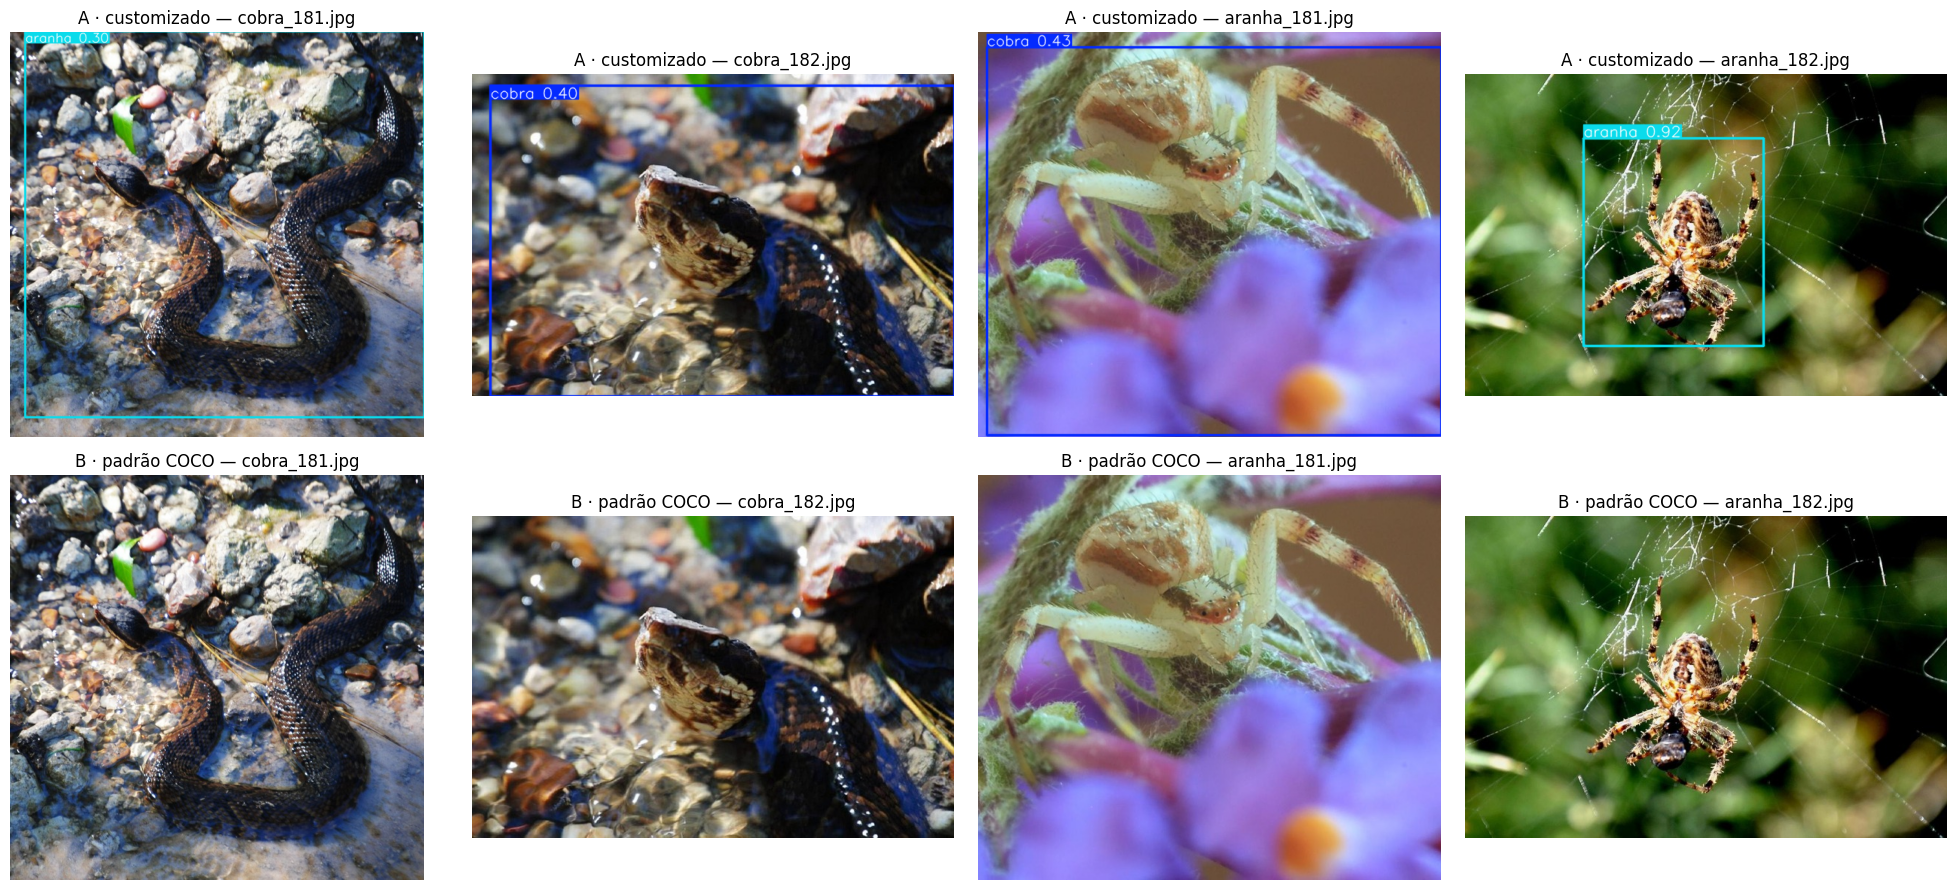

In [8]:
# O YOLOv5 troca o backend do matplotlib para Agg ao ser carregado; garante a exibição inline
%matplotlib inline
# Lado a lado: YOLO customizado × YOLO padrão em 4 imagens de teste
amostra = [p for p, y in zip(X_test, y_test) if y == 0][:2] + [p for p, y in zip(X_test, y_test) if y == 1][:2]
fig, axs = plt.subplots(2, 4, figsize=(20, 9))
for j, p in enumerate(amostra):
    for i, (m, titulo) in enumerate(((yolo_custom, 'A · customizado'), (yolo_coco, 'B · padrão COCO'))):
        axs[i, j].imshow(m(str(p), size=640).render()[0]); axs[i, j].axis('off')
        axs[i, j].set_title(f'{titulo} — {p.name}')
plt.tight_layout(); plt.show()

## 4. Abordagem C — CNN treinada do zero

Rede convolucional simples em **TensorFlow/Keras**, sem nenhum peso pré-treinado. Como a base é minúscula (312 imagens de treino), a arquitetura é propositalmente pequena e regularizada:

- *Data augmentation* (espelhamento, rotação, zoom, contraste) para criar variações a cada época;
- 4 blocos `Conv2D → BatchNorm → MaxPool` (32→64→128→256 filtros);
- `GlobalAveragePooling` no lugar de `Flatten` (menos parâmetros, menos overfitting) + `Dropout(0.4)`;
- saída `sigmoid` (problema binário: 0 = cobra, 1 = aranha);
- `BatchNormalization(momentum=0.9)`: com poucos passos por época, o valor padrão (0,99) deixa as estatísticas defasadas e a rede erra na inferência;
- `EarlyStopping` na perda de validação, restaurando os melhores pesos, **só a partir da época 10** (para não voltar a pesos quase aleatórios das primeiras épocas).

As imagens são reorganizadas em pastas por classe (`cls/<split>/<classe>/`), o formato esperado pelo `image_dataset_from_directory`.

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
tf.keras.utils.set_random_seed(SEED)                       # reprodutibilidade

# Reorganiza o dataset de detecção em pastas por classe (classificação)
CLS_DIR = Path('/content/cls')
for split in ('train', 'val', 'test'):
    for arq in (DATASET / split / 'images').glob('*.jpg'):
        destino = CLS_DIR / split / arq.name.split('_')[0]
        destino.mkdir(parents=True, exist_ok=True)
        shutil.copy(arq, destino / arq.name)

def carregar(split, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        CLS_DIR / split, labels='inferred', label_mode='binary', class_names=CLASSES,
        image_size=(IMG_CNN, IMG_CNN), batch_size=16, shuffle=shuffle, seed=SEED)

ds_train, ds_val = carregar('train', True), carregar('val', False)
ds_train = ds_train.cache().prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.cache().prefetch(tf.data.AUTOTUNE)

Found 320 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


In [10]:
def criar_cnn():
    aug = models.Sequential([layers.RandomFlip('horizontal'), layers.RandomRotation(0.1),
                             layers.RandomZoom(0.15), layers.RandomContrast(0.15)], name='augmentation')
    m = models.Sequential([layers.Input((IMG_CNN, IMG_CNN, 3)), aug, layers.Rescaling(1 / 255)], name='cnn_do_zero')
    for f in (32, 64, 128, 256):                               # blocos convolucionais
        m.add(layers.Conv2D(f, 3, padding='same', use_bias=False))
        m.add(layers.BatchNormalization(momentum=0.9)); m.add(layers.ReLU())   # momentum 0.9: estatísticas se ajustam rápido (poucos passos por época); m.add(layers.MaxPooling2D())
    m.add(layers.GlobalAveragePooling2D()); m.add(layers.Dropout(0.4))
    m.add(layers.Dense(1, activation='sigmoid'))
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

cnn = criar_cnn()
cnn.summary()

Model: "cnn_do_zero"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 160, 160, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 160, 160, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 160, 160, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 160, 160, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 160, 160, 128)  │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 160, 160, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 160, 160, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 160, 160, 256)  │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 160, 160, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 160, 160, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,113 (1.49 MB)

 Trainable params: 389,153 (1.48 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/100
20/20 - 19s - 950ms/step - accuracy: 0.6062 - loss: 0.7530 - val_accuracy: 0.4750 - val_loss: 0.9443
Epoch 2/100
20/20 - 6s - 322ms/step - accuracy: 0.6187 - loss: 0.6730 - val_accuracy: 0.4250 - val_loss: 0.8379
Epoch 3/100
20/20 - 7s - 329ms/step - accuracy: 0.6469 - loss: 0.6309 - val_accuracy: 0.6500 - val_loss: 0.6497
Epoch 4/100
20/20 - 7s - 328ms/step - accuracy: 0.7188 - loss: 0.5988 - val_accuracy: 0.6500 - val_loss: 0.7179
Epoch 5/100
20/20 - 7s - 327ms/step - accuracy: 0.7125 - loss: 0.5782 - val_accuracy: 0.6500 - val_loss: 0.7470
Epoch 6/100
20/20 - 7s - 335ms/step - accuracy: 0.6875 - loss: 0.5789 - val_accuracy: 0.7250 - val_loss: 0.6448
Epoch 7/100
20/20 - 7s - 336ms/step - accuracy: 0.7219 - loss: 0.5745 - val_accuracy: 0.6750 - val_loss: 0.7407
Epoch 8/100
20/20 - 7s - 340ms/step - accuracy: 0.6938 - loss: 0.5965 - val_accuracy: 0.7500 - val_loss: 0.6906
Epoch 9/100
20/20 - 7s - 344ms/step - accuracy: 0.7063 - loss: 0.5592 - val_accuracy: 0.6500 - val_loss

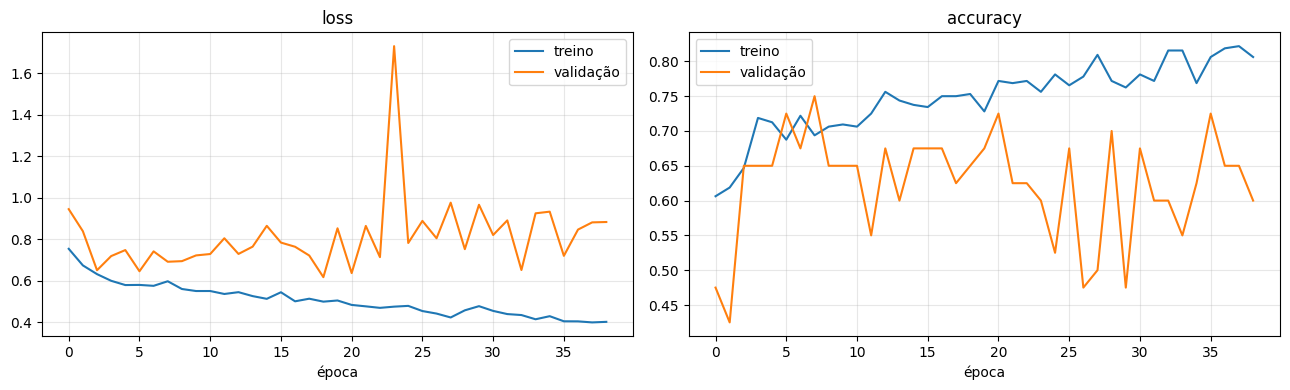

In [11]:
# O YOLOv5 troca o backend do matplotlib para Agg ao ser carregado; garante a exibição inline
%matplotlib inline
# start_from_epoch=10: não restaura pesos das primeiras épocas, quando a rede ainda é quase aleatória
parada = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, start_from_epoch=10)
t0 = time.time()
historico = cnn.fit(ds_train, validation_data=ds_val, epochs=100, callbacks=[parada], verbose=2)
t_treino_C = time.time() - t0
print(f'Treino: {t_treino_C:.1f} s em {len(historico.history["loss"])} épocas (melhor: {np.argmin(historico.history["val_loss"]) + 1})')

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for ax, k in zip(axs, ('loss', 'accuracy')):
    ax.plot(historico.history[k], label='treino'); ax.plot(historico.history['val_' + k], label='validação')
    ax.set_title(k); ax.set_xlabel('época'); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

In [12]:
def prep_cnn(arq):
    # Mesmo pré-processamento do treino: redimensiona para IMG_CNN x IMG_CNN (rescaling está dentro do modelo)
    img = tf.keras.utils.load_img(arq, target_size=(IMG_CNN, IMG_CNN))
    return tf.expand_dims(tf.keras.utils.img_to_array(img), 0)

def classe_cnn(arq):
    return int(cnn(prep_cnn(arq), training=False).numpy()[0, 0] >= 0.5)

pred_C = [classe_cnn(p) for p in X_test]
t_inf_C = cronometrar(classe_cnn, X_test)
res_C = avaliar('C · CNN do zero', y_test, pred_C)
res_C

{'abordagem': 'C · CNN do zero',
 'acurácia': 0.725,
 'F1 macro': 0.7248280175109443,
 'sem detecção': 0}

## 5. Comparação

In [13]:
# Tabela consolidada dos quatro critérios
tabela = pd.DataFrame([res_A, res_B, res_C])
tabela['tempo de treino/customização (s)'] = [t_treino_A, 0.0, t_treino_C]
tabela['inferência (ms/img)'] = [t_inf_A, t_inf_B, t_inf_C]
tabela['parâmetros (M)'] = [sum(p.numel() for p in yolo_custom.parameters()) / 1e6,
                            sum(p.numel() for p in yolo_coco.parameters()) / 1e6, cnn.count_params() / 1e6]
json.dump(tabela.to_dict('records'), open(RESULTS / 'comparacao_entrega2.json', 'w'), indent=2, default=float)
tabela.round(3)

,abordagem,acurácia,F1 macro,sem detecção,tempo de treino/customização (s),inferência (ms/img),parâmetros (M)
0,A · YOLOv5s customizado (60 ép.),0.825,0.878,5,383.059,17.483,7.016
1,B · YOLOv5s padrão (COCO),0.000,0.000,40,0.000,16.541,7.226
2,C · CNN do zero,0.725,0.725,0,273.495,23.639,0.390


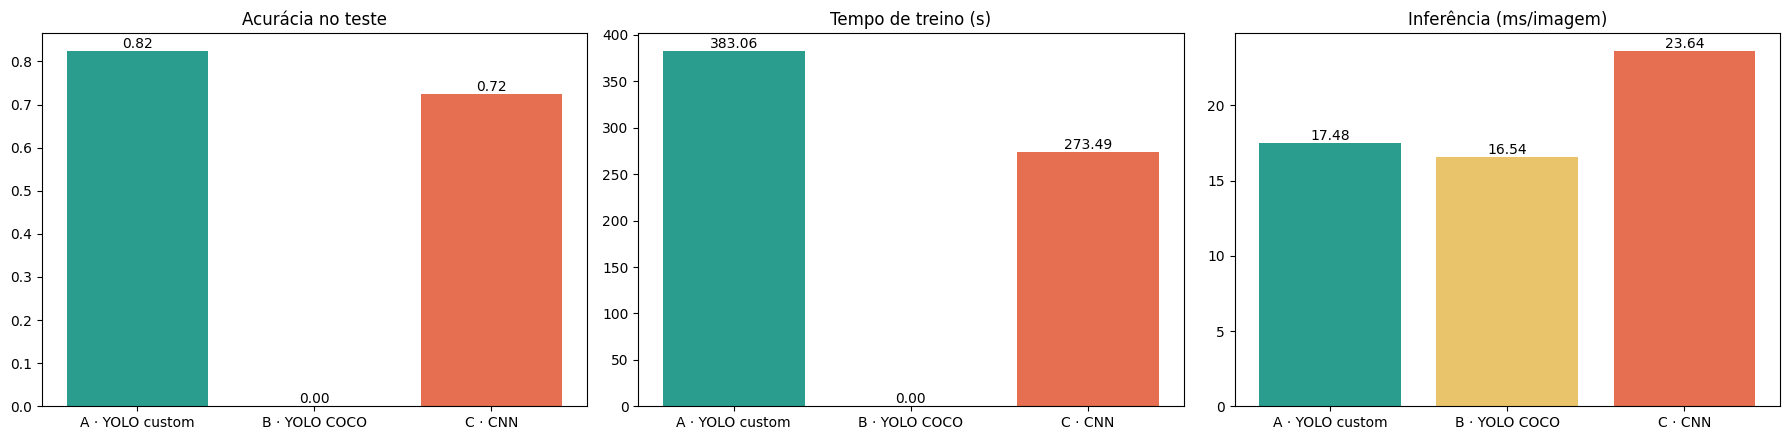

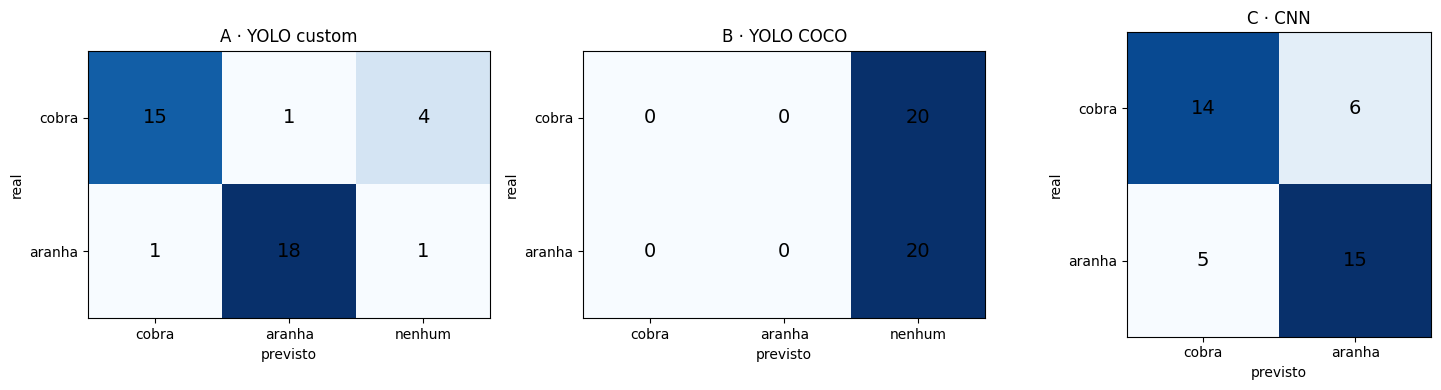

In [14]:
# O YOLOv5 troca o backend do matplotlib para Agg ao ser carregado; garante a exibição inline
%matplotlib inline
fig, axs = plt.subplots(1, 3, figsize=(18, 4.5))
cores = ['#2a9d8f', '#e9c46a', '#e76f51']
rot = ['A · YOLO custom', 'B · YOLO COCO', 'C · CNN']
for ax, col, titulo in zip(axs, ['acurácia', 'tempo de treino/customização (s)', 'inferência (ms/img)'],
                           ['Acurácia no teste', 'Tempo de treino (s)', 'Inferência (ms/imagem)']):
    barras = ax.bar(rot, tabela[col], color=cores); ax.bar_label(barras, fmt='%.2f'); ax.set_title(titulo)
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, pred, titulo in zip(axs, (pred_A, pred_B, pred_C), rot):
    plot_confusao(ax, y_test, pred, titulo)
plt.tight_layout(); plt.show()

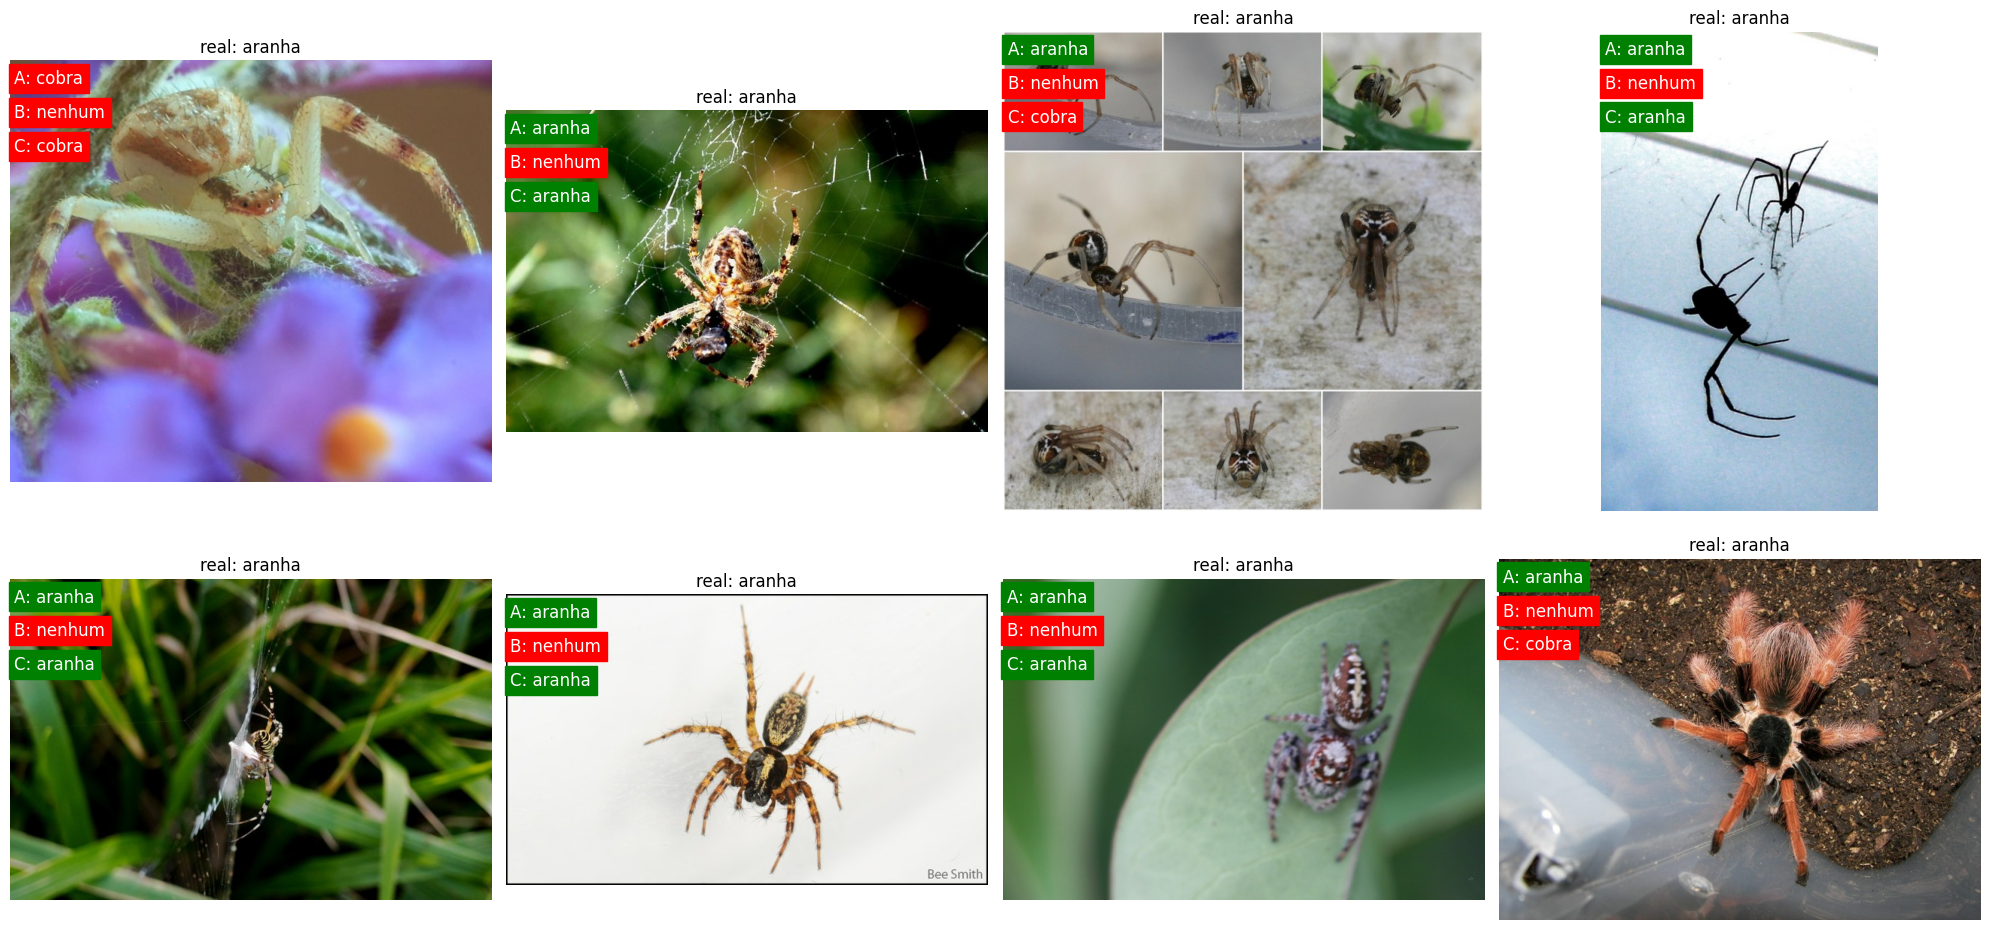

In [15]:
# O YOLOv5 troca o backend do matplotlib para Agg ao ser carregado; garante a exibição inline
%matplotlib inline
# Previsões das três abordagens em cada imagem de teste (verde = acerto, vermelho = erro)
nome = lambda c: 'nenhum' if c == -1 else CLASSES[c]
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for ax, p, y, a, b, c in zip(axs.flat, X_test, y_test, pred_A, pred_B, pred_C):
    ax.imshow(Image.open(p)); ax.axis('off')
    ax.set_title(f'real: {CLASSES[y]}', fontsize=12)
    for k, (r, v) in enumerate((('A', a), ('B', b), ('C', c))):
        ax.text(5, 30 + 45 * k, f'{r}: {nome(v)}', color='white', fontsize=12,
                backgroundcolor='green' if v == y else 'red')
plt.tight_layout(); plt.show()

In [16]:
# Análise numérica gerada a partir dos resultados desta execução
from IPython.display import Markdown
t = tabela.set_index('abordagem')
mais_preciso = t['acurácia'].idxmax(); mais_rapido = t['inferência (ms/img)'].idxmin()
Markdown(f'''
- **Mais preciso no teste:** {mais_preciso} ({t.loc[mais_preciso, "acurácia"]:.0%}).
- **Inferência mais rápida:** {mais_rapido} ({t.loc[mais_rapido, "inferência (ms/img)"]:.1f} ms/img).
- **YOLO padrão na base completa:** acurácia {res_B_all["acurácia"]:.0%}, {res_B_all["sem detecção"]} imagens sem detecção de uma classe correspondente (o COCO não tem cobra nem aranha).
- **Custo de treino:** customizar o YOLO levou {t_treino_A/60:.1f} min; a CNN, {t_treino_C/60:.1f} min; o YOLO padrão, zero.
''')


- **Mais preciso no teste:** A · YOLOv5s customizado (60 ép.) (82%).
- **Inferência mais rápida:** B · YOLOv5s padrão (COCO) (16.5 ms/img).
- **YOLO padrão na base completa:** acurácia 0%, 400 imagens sem detecção de uma classe correspondente (o COCO não tem cobra nem aranha).
- **Custo de treino:** customizar o YOLO levou 6.4 min; a CNN, 4.6 min; o YOLO padrão, zero.


## 6. Avaliação crítica

### Facilidade de uso / integração

| Abordagem | Avaliação |
|---|---|
| **B · YOLO padrão** | A mais simples: uma linha (`torch.hub.load`) e já detecta. Não exige rotulação nem treino. Em compensação, só reconhece o vocabulário do COCO — *cobra* e *aranha* não existem nele, então para este problema ele simplesmente não serve. |
| **A · YOLO customizado** | Exige o trabalho mais caro do projeto: **rotular caixas** (Make Sense) e montar o YAML. Depois disso, o treino é um único comando e a integração é idêntica à do modelo padrão (mesmo `torch.hub`, mesmo `detect.py`, exportação para ONNX/TFLite). |
| **C · CNN do zero** | Rotulação trivial (basta separar em pastas), mas exige **projetar a arquitetura**, escolher regularização e ajustar hiperparâmetros. Entrega só "qual classe é a imagem", sem posição nem contagem de objetos. |

### Precisão

- O **YOLO customizado** tende a ser o mais preciso porque une duas vantagens: pesos pré-treinados em milhões de imagens e ajuste fino às nossas classes. Ele também localiza e **conta** os animais e diz *onde* estão na imagem, o que nenhum classificador faz.
- O **YOLO padrão** não acerta nenhuma imagem: cobra e aranha estão fora do seu vocabulário. A lista de classes COCO vistas (seção 3) mostra o que ele "chuta" — tipicamente `bird`, `person` ou objetos do fundo, ou nada. **Um modelo genérico não resolve uma classe que ele nunca viu.**
- A **CNN do zero** aprende com 312 imagens de treino. Cobra × aranha tem silhuetas bem diferentes, então ela pode acertar bem no teste, mas tende a aprender atalhos (teia ao fundo, cor do solo, folhagem) e generaliza mal para câmeras e cenários novos. A distância entre as curvas de treino e validação indica o grau de overfitting.
- Com **38 imagens de teste**, cada erro vale cerca de 2,6 pontos de acurácia: diferenças de um ou dois acertos entre abordagens ainda não são estatisticamente significativas.

### Tempo de treinamento / customização

- **B:** zero. **C:** o mais rápido de treinar entre os treináveis (rede pequena, imagens de 160 px). **A:** alguns minutos de GPU (seção 7 da Entrega 1), ainda baixo graças ao *transfer learning*.
- O custo dominante de **A** não é a GPU, e sim a **rotulação de caixas**, que cresce com o tamanho da base.

### Tempo de inferência

- A CNN é a menor rede (cerca de 0,4 M de parâmetros contra ~7 M do YOLOv5s), mas **na medição deste Colab ela não foi a mais rápida** (veja a tabela da seção 5). O tempo medido inclui carregar o JPEG do Drive e chamar o modelo Keras imagem por imagem, sem lotes nem `tf.function`, e esse custo fixo pesa mais que o cálculo da rede. Número de parâmetros indica custo de hardware, não garante menor latência medida.
- A e B têm **a mesma arquitetura** e, portanto, tempos próximos; as diferenças vêm do número de caixas que passam pelo NMS e do ruído de medição.
- Os três ficam na casa de dezenas de milissegundos por imagem na GPU (acima de 40 imagens por segundo): todos atendem vídeo em tempo real. A escolha deve ser guiada por precisão e pelo tipo de resposta necessária (classe × localização).

### Recomendação para a FarmTech

| Necessidade do cliente | Abordagem |
|---|---|
| Localizar e contar animais peçonhentos, alertas por região da imagem (galpão, curral) | **A · YOLO customizado** |
| Prova de conceito imediata com objetos que já estão no COCO (pessoas, veículos, gado) | **B · YOLO padrão** |
| Triagem barata "há cobra ou aranha nesta foto?" em hardware muito limitado | **C · CNN** (idealmente com *transfer learning*, não do zero) |

### Limitações desta comparação

- Base pequena e de um único domínio (fotos do Open Images); os números absolutos não se transferem para câmeras reais.
- O conjunto de teste tem 38 imagens; o ideal seria validação cruzada ou uma base de teste ainda maior.
- O YOLO padrão foi avaliado fora do seu vocabulário; ele mostra o limite de um modelo genérico, não sua qualidade em classes que conhece.
- Tempos medidos no Colab variam com a GPU alocada; a comparação relativa é mais confiável que os valores absolutos.